In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats as st
from math import comb, log
import math
import scipy.special as sp
from scipy.optimize import brentq
import gcm
from copy import deepcopy
import ast
from scipy.interpolate import make_interp_spline, make_smoothing_spline
import joypy as jp
from tqdm import tqdm
from numba import jit
from functools import *
import time
from scipy.stats import loglaplace,chi2

from labellines import labelLine, labelLines

colors_7 = ['#5c3e81', '#944087', '#c6447f', '#ed536c', '#ff7151', '#ff9931', '#ffc400']
purple_7 = ['#5c3e81', '#745695', '#8b6faa', '#a489be', '#bca4d4', '#d5bfe9', '#eedbff']
orange_7 = ['#ff9931', '#ffa44a', '#ffaf60', '#ffba76', '#ffc58c', '#ffcfa2', '#ffdab8']
plt.rcParams["figure.figsize"] = (16,10)
matplotlib.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",        
    "font.serif": ["DejaVu Serif"],  
})

## General ideas 

This model is based on the work in (St-Onge, 2021). We complement the model in this article by allowing the nodes to be **active** or **inactive**, which means they either have a natural tendency to adopt prophylactic measures or they don't.

The model uses **approximate master equations** (AME) to trace the limiting behavior of the epidemic. In general, the probabilities defined in the following use a frequentist definition. The parameters in the next cell are as follows:

- A is the (expected) proportion of active individuals in the total population. These individuals are chosen randomly
- $\beta$ is the unprotected transmission parameter.
- eff multiplies beta for active groups. It thus quantifies the efficiency of prophylactic measures.
- $n_{min}$ and $n_{max}$ are the maximal and minimal group sizes.
- $m_{min}$ and $m_{max}$ are the maximal and minimal node memberships.

The model will most often use heterogeneous membership and group size distributions, such that $p_n \sim n^{-\gamma_n}$ and $g_m \sim m^{-\gamma_m}$.

In [3]:
# Helpers
def p(n, gamma_n, n_min=2, n_max=80):
    p_n = [n**(-gamma_n) for n in range(n_min, n_max+1)]
    p_n_norm = sum(p_n)
    return n**(-gamma_n)/p_n_norm

def ave_p(x, gamma_n, n_min=2, n_max=80):
    return np.sum([x[n-n_min]*p(n, gamma_n, n_min=n_min, n_max=n_max) for n in range(n_min, n_max+1)])

def normalize(arr):
    Z = np.sum(arr)
    if Z == 0:
        return arr * 0
    return arr / Z

def ave_deg(gamma_n, gamma_m, n_min, n_max, m_min, m_max):
    m_ave = ave_p(range(m_min, m_max+1), gamma_m, n_min=m_min, n_max=m_max)
    n_ave = ave_p(range(n_min, n_max+1), gamma_n, n_min=m_min, n_max=m_max)
    exc_n_ave = ave_p([n*(n-1) for n in range(n_min, n_max+1)], gamma_n, n_min=m_min, n_max=m_max)
    return m_ave*exc_n_ave/n_ave

def var_deg(gamma_n, gamma_m, n_min, n_max, m_min, m_max):
    m_ave = ave_p(range(m_min, m_max+1), gamma_m, n_min=m_min, n_max=m_max)
    m_ave2 = ave_p([m**2 for m in range(m_min, m_max+1)], gamma_m, n_min=m_min, n_max=m_max)
    m_var = m_ave2 - m_ave**2
    n_ave = ave_p(range(n_min, n_max+1), gamma_n, n_min=m_min, n_max=m_max)
    n_ave2 = ave_p([n**2 for n in range(n_min, n_max+1)], gamma_n, n_min=m_min, n_max=m_max)
    n_ave3 = ave_p([n**3 for n in range(n_min, n_max+1)], gamma_n, n_min=m_min, n_max=m_max)
    return m_ave*(n_ave3/n_ave - (n_ave2/n_ave)**2) + m_var*((n_ave2/n_ave)-1)**2

def coupling(gamma_n, gamma_m, n_min, n_max, m_min, m_max):
    m_ave = ave_p(range(m_min, m_max+1), gamma_m, n_min=m_min, n_max=m_max)
    exc_m_ave = ave_p([m*(m-1) for m in range(m_min, m_max+1)], gamma_m, n_min=m_min, n_max=m_max)
    n_ave = ave_p(range(n_min, n_max+1), gamma_n, n_min=n_min, n_max=n_max)
    exc_n_ave = ave_p([n*(n-1) for n in range(n_min, n_max+1)], gamma_n, n_min=n_min, n_max=n_max)
    return (exc_m_ave/m_ave)*(exc_n_ave/n_ave)

### Structural probabilities

In this model, the nodes' behavior is *adaptative* and subject to conformity pressure, such that all nodes in a group behave the same *in that group*. That is, the probability that a group adopts active behavior as a whole increases with the fraction of active nodes in the group.

To properly account for conformity and the behavior of groups, we define the following structural probabilities:
- $P_{n^+|n}$, the composition distribution, is the probability that a group of size n contains $n^+$ active nodes. In the absence of homophily, this is a binomial distribution.
- $P_{\{+\}|n, n^+}$, the response distribution, is the probability that a group of size n is active if it has $n^+$ active nodes.
- $P_{\{\pm\}|n} \equiv \sum_{n^+=0}^n P_{\{\pm\}|n, n^+} P_{n^+|n}$ is the probability that a randomly chosen group of size n is of type $\{\pm\}$.
- $P_{\{+\}|n, -}$ is the probability that a group of size n is active given that it contains at least one passive node.
- $P_{\{+\}, n|+}$ is the probability that, for a randomly chosen active node, a group to which it belongs is active and of size n.
- Conversely, $P_{\{+\}, n|-}$ is the probability that, for a randomly chosen passive node, a group to which it belongs is active and of size n.
- $A_{\{+\}|n}$ is the probability to draw an active node in a randomly chosen active group of size n.
- Conversely, $A_{\{-\}|n}$ is the probability to draw an active node in a randomly chosen passive group of size n.

In [4]:
#Composition distribution P_{n^+|n}
def composition_distribution(n, A, h):
    P = np.zeros(n+1)
    p1 = h + A*(1-h)
    q1 = (1-h)*(1-A)
    p2 = (1-h)*A
    q2 = 1 - A + h*A

    for k in range(n+1):
        P[k] = (
            A * comb(n,k) * p1**k * q1**(n-k) +
            (1-A) * comb(n,k) * p2**k * q2**(n-k)
        )
    return normalize(P)

# Response distribution P_{ {+} | n, n^+ }
def response_probability(n_plus, n, tau, s):
    if tau==1:
        tau = 1-1e-8
    elif tau==0:
        tau = 1e-8
    r = - np.log(2)/np.log(tau)
    n_scaled = n_plus/n
    if n_plus == 0:
        return 0
    elif n_plus == n:
        return 1
    else:
        return (1-n_scaled**r)**(-s)/((1-n_scaled**r)**(-s) + n_scaled**(-s*r))

# Group-type marginals P_{\{±\}| n }
def P_pm_given_n(n, P_nplus_n, tau, s):
    P_plus = 0.0
    for n_plus, P in enumerate(P_nplus_n):
        P_plus += P * response_probability(n_plus, n, tau, s)
    return P_plus, 1-P_plus

#Conditional P_{\{+\}|n, -}
def P_plus_given_n_minus(n, P_nplus_n, tau, s):
    return (P_pm_given_n(n, P_nplus_n, tau, s)[0] - P_nplus_n[-1])/(1-P_nplus_n[-1])

# Conditional P_{\{±\}, n|±}
def P_pm_n_given_pm(n, P_nplus_n, tau, s):
    # For node type +
    w_plus = np.array([n_plus * P_nplus_n[n_plus] for n_plus in range(n+1)])
    if w_plus.sum() == 0: w_plus = np.ones_like(w_plus)
    Pp = np.zeros(2)
    for n_plus in range(n+1):
        resp = response_probability(n_plus, n, tau, s)
        Pp[0] += w_plus[n_plus] * resp
        Pp[1] += w_plus[n_plus] * (1-resp)
    Pp = normalize(Pp)

    # For node type –
    w_minus = np.array([(n-np) * P_nplus_n[np] for np in range(n+1)])
    if w_minus.sum() == 0: w_minus = np.ones_like(w_minus)
    Pm = np.zeros(2)
    for n_plus in range(n+1):
        resp = response_probability(n_plus, n, tau, s)
        Pm[0] += w_minus[n_plus] * resp
        Pm[1] += w_minus[n_plus] * (1-resp)
    Pm = normalize(Pm)

    return {
        ("+", "{+}"): Pp[0], ("+", "{-}"): Pp[1],
        ("-", "{+}"): Pm[0], ("-", "{-}"): Pm[1],
    }

# A_n^{±}
def A_n_pm_values(n, P_nplus_n, tau, s):
    P_plus_n, _ = P_pm_given_n(n, P_nplus_n, tau, s)
    num_plus = 0.0
    num_minus = 0.0

    for n_plus, P in enumerate(P_nplus_n):
        resp = response_probability(n_plus, n, tau, s)
        num_plus  += n_plus * P * resp
        num_minus += n_plus * P * (1 - resp)

    A_plus  = num_plus  / (n * P_plus_n)       if P_plus_n     > 0 else 0.0
    A_minus = num_minus / (n * (1 - P_plus_n)) if (1-P_plus_n) > 0 else 0.0
    return A_plus, A_minus

## Mean fields

The approximate equation framework makes use of mean-field approximations to account for the interactions between groups. The mean fields are as follows:

- $r^{\{+\}}$ is the average infection rate associated to a group to which belongs a randomly chosen _active_ node.
- $r^{\{-\}}$ is the average infection rate associated to a group to which belongs a randomly chosen _passive_ node.
- $\rho_{n}^{\{+\}}$ is the average infection rate associated to an external group to which belongs a susceptible node chosen randomly within an _active_ group of size n.
- $\rho_{n}^{\{-\}}$ is the average infection rate associated to an external group to which belongs a susceptible node chosen randomly within a _passive_ group of size n.

In [5]:
# Compute r^± from current c state
def compute_r_pm(p_n, c_state, P_sigma_n_pm_dict, beta_plus, beta_minus, node_type):
    num = 0.0
    den = 0.0

    for n, p in p_n.items():
        for sigma in ["{+}", "{-}"]:
            P_sigma = P_sigma_n_pm_dict[(node_type, sigma)][n]
            c = c_state[(n, sigma)]
            beta = beta_plus if sigma == "{+}" else beta_minus

            i = np.arange(n+1)
            S = (n - i)

            num += p * P_sigma * np.sum(beta * i * S * c)
            den += p * P_sigma * np.sum(S * c)

    return num/den if den > 0 else 0.0

# Excess membership
def excess_sus_membership(g_m, v_s_m_pm):
    num = 0
    den = 0
    for m, g in g_m.items():
        vs = v_s_m_pm[m]
        num += (m-1)*m*vs*g
        den += m*vs*g
    return num/den if den > 0 else 0.0

#Compute rho_n^\pm
def compute_rho_n_pm(g_m, v_s_plus, v_s_minus, r_plus, r_minus, A_n_sigma):
    m_ex_plus  = excess_sus_membership(g_m, v_s_plus)
    m_ex_minus = excess_sus_membership(g_m, v_s_minus)

    rho_plus  = r_plus  * m_ex_plus
    rho_minus = r_minus * m_ex_minus
    theta_plus = sum(g_m[m] * v_s_plus[m]  for m in g_m)
    theta_minus = sum(g_m[m] * v_s_minus[m] for m in g_m)

    rho_n_sigma = {}
    for n in p_n:
        for sigma in ["{+}", "{-}"]:

            A = A_n_sigma[(n, sigma)]          
            
            # susceptible-weighted fraction of + nodes inside (n,σ)
            num = A * theta_plus
            den = A * theta_plus + (1 - A) * theta_minus
            if den > 0:
                A_S = num / den
            else:
                A_S = A 

            # corrected external infection rate for this group type
            rho_n_sigma[(n, sigma)] = A_S * rho_plus + (1 - A_S) * rho_minus
    return rho_n_sigma

## Stationary state solver

The stationary state solver numerically finds the solution to the stationary state equations, which are as follows:

$$v_{s|m, \pm} = \frac{1}{1+mr^\pm}$$
$$c_{i|n, \{\pm\}} = c_{0|n, \{\pm\}}\binom{n}{i}(\beta^\pm)^i\left(\frac{\rho_n^{\{\pm\}}}{\beta^\pm}\right)^{(i)}$$

with

$$c_{0|n, \{\pm\}} = 1-\sum_{i=1}^n c_{i|n, \{\pm\}}.$$

We solve these equations by simply iterating them until they converge.

In [6]:
# Stationary group distribution c_{i|n,{±}} 
def stationary_c_distribution(n, beta_sigma, rho_n_sigma):
    c = np.zeros(n+1)
    c[0] = 1.0
    for i in range(1, n+1):
        prod = 1.0
        for j in range(i):
            prod *= (beta_sigma * j + rho_n_sigma)
        c[i] = comb(n, i) * prod
    return normalize(c)

# Main stationary solver
def stationary_state(A, h, epsilon, beta_minus, p_n, g_m, s, tau,
                     max_iter=200, tol=1e-10, init_state=None):

    beta_plus = epsilon * beta_minus

    # Composition distributions
    P_nplus_n = {n: composition_distribution(n, A, h) for n in p_n}

    # A_n^σ and marginals
    A_n_sigma = {}
    P_sigma_n = {}
    for n in p_n:
        P_plus_n, P_minus_n = P_pm_given_n(n, P_nplus_n[n], tau, s)
        P_sigma_n[n] = {"{+}": P_plus_n, "{-}": P_minus_n}
        A_plus, A_minus = A_n_pm_values(n, P_nplus_n[n], tau, s)
        A_n_sigma[(n, "{+}")] = A_plus
        A_n_sigma[(n, "{-}")] = A_minus

    # Conditional P_{σ|n,±}
    P_sigma_n_pm_dict = {("+","{+}"): {}, ("+","{-}"): {},
                         ("-","{+}"): {}, ("-","{-}"): {}}
    for n in p_n:
        d = P_pm_n_given_pm(n, P_nplus_n[n], tau, s)
        for key in d:
            P_sigma_n_pm_dict[key][n] = d[key]
    
    if init_state is None:
        # Init group distributions
        c_state = {(n, sigma): normalize(np.full(n+1, 1/(n+2)))
                   for n in p_n for sigma in ["{+}", "{-}"]}

        # Init node susceptibilities
        v_s_plus  = {m: 0.8 for m in g_m}
        v_s_minus = {m: 0.6 for m in g_m}
    
    else:
        c_state = init_state["c_state"]
        v_s_plus = init_state["v_s_plus"]
        v_s_minus = init_state["v_s_minus"]

    for _ in range(max_iter):

        # r^+, r^-
        r_plus  = compute_r_pm(p_n, c_state, P_sigma_n_pm_dict, beta_plus, beta_minus, "+")
        r_minus = compute_r_pm(p_n, c_state, P_sigma_n_pm_dict, beta_plus, beta_minus, "-")

        # v_s
        new_v_s_plus  = {m: 1/(1 + m*r_plus)  for m in g_m}
        new_v_s_minus = {m: 1/(1 + m*r_minus) for m in g_m}

        # ρ^±
        m_ex_plus  = excess_sus_membership(g_m, new_v_s_plus)
        m_ex_minus = excess_sus_membership(g_m, new_v_s_minus)

        rho_plus  = r_plus  * m_ex_plus
        rho_minus = r_minus * m_ex_minus

        # ρ_n^σ
        theta_plus = sum(g_m[m] * new_v_s_plus[m]  for m in g_m)
        theta_minus = sum(g_m[m] * new_v_s_minus[m] for m in g_m)

        rho_n_sigma = compute_rho_n_pm(g_m, new_v_s_plus, new_v_s_minus, r_plus, r_minus, A_n_sigma)   # overwrite previous version

        # Update c_state
        new_c_state = {}
        for n in p_n:
            for sigma in ["{+}", "{-}"]:
                beta_s = beta_plus if sigma == "{+}" else beta_minus
                rho_s = rho_n_sigma[(n, sigma)]
                new_c_state[(n, sigma)] = stationary_c_distribution(
                    n, beta_s, rho_s
                )

        # Convergence criterion
        diff = 0
        for key in c_state:
            diff += np.max(np.abs(new_c_state[key] - c_state[key]))
        for m in g_m:
            diff += abs(new_v_s_plus[m]  - v_s_plus[m])
            diff += abs(new_v_s_minus[m] - v_s_minus[m])

        c_state = new_c_state
        v_s_plus = new_v_s_plus
        v_s_minus = new_v_s_minus

        if diff < tol:
            break

    return dict(
        r_plus=r_plus, r_minus=r_minus,
        rho_plus=rho_plus, rho_minus=rho_minus,
        v_s_plus=v_s_plus, v_s_minus=v_s_minus,
        rho_n_sigma=rho_n_sigma,
        c_state=c_state,
        A_n_sigma=A_n_sigma,
        P_sigma_n=P_sigma_n,
    )

## Epidemic threshold

In [76]:
def A_n(beta, n):
    """
    Exact for integer n >= 2:
    A_n(beta) = sum_{k=0}^{n-2} C(n-2, k) * k! * beta**k
    """
    s = 0.0
    for k in range(n-1):  # 0 .. n-2
        s += math.comb(n-2, k) * math.factorial(k) * (beta**k)
    return s

def F(beta, ave_m, ave_n, exc_ave_m, gamma_n, gamma_m, n_min, n_max, m_min, m_max):
    denom = ave_n*ave_m
    num = ave_p([n*(n-1)*A_n(beta, n) for n in range(n_min, n_max+1)], 
                   gamma_n, n_min=n_min, n_max=n_max)
    return beta*exc_ave_m*num/denom - 1

def solve_beta(gamma_m, gamma_n,
                    m_min=2, m_max=80,
                    n_min=2, n_max=80):
    # Bracket the root
    ave_n = ave_p(range(n_min, n_max+1), 
                   gamma_n, n_min=n_min, n_max=n_max)
    ave_m = ave_p(range(m_min, m_max+1), 
                   gamma_m, n_min=m_min, n_max=m_max)
    exc_ave_m = ave_p([m*(m-1) for m in range(m_min, m_max+1)], 
                   gamma_m, n_min=m_min, n_max=m_max)
    beta_lo = 1/(coupling(gamma_n, gamma_m, n_min, n_max, m_min, m_max)+(n_max-2))
    beta_hi = 1/coupling(gamma_n, gamma_m, n_min, n_max, m_min, m_max)

    # Ensure sign change
    while F(beta_hi, ave_m, ave_n, exc_ave_m, gamma_n, gamma_m, n_min, n_max, m_min, m_max) < 0:
        beta_hi *= 2.0

    return brentq(F, beta_lo, beta_hi,
                  args=(ave_m, ave_n, exc_ave_m, gamma_n, gamma_m, n_min, n_max, m_min, m_max))

def w_plus(tau, s, h, A, n_min, n_max, gamma_n):

    numerator = 0.0
    denominator = 0.0

    sizes = np.arange(n_min, n_max + 1)

    p_n = sizes**(-gamma_n)
    p_n = p_n / p_n.sum()

    for n, pn in zip(sizes, p_n):

        if n < 2 or pn == 0:
            continue

        P_nplus_n = composition_distribution(n, A, h)
        probs = P_pm_n_given_pm(n, P_nplus_n, tau, s)

        P_star_minus = probs[("-", "{+}")]

        numerator   += (n - 1) * pn * P_star_minus
        denominator += (n - 1) * pn

    return numerator / denominator if denominator > 0 else 0.0

def analytic_threshold(s, h, tau, A, eff, gamma_n, gamma_m, n_min, n_max, m_min, m_max):
    w_p = w_plus(tau, s, h, A, n_min, n_max, gamma_n)
    beta_0 = solve_beta(gamma_m, gamma_n, n_min=n_min, n_max=n_max, m_min=m_min, m_max=m_max)
    return beta_0/(1-(1-eff)*w_p)

def threshold_from_state(s, h, tau, A, epsilon, gamma_n, gamma_m, n_min, n_max, m_min, m_max,
                         max_iter=200, tol_sim=1e-10, init_beta=None, tol_thresh=1e-5):

    p_n = {n: p(n, gamma_n, n_min=n_min, n_max=n_max) for n in range(n_min, n_max+1)}
    g_m = {m: p(m, gamma_m, n_min=m_min, n_max=m_max) for m in range(m_min, m_max+1)}

    if init_beta is None:
        beta = 1/n_max
    else:
        beta = init_beta
        
    out = stationary_state(A, h, epsilon, beta, p_n, g_m, s, tau,
                     max_iter=max_iter, tol=tol_sim, init_state=None)
    
    diff = 1/(2*n_max)
    c_state = out['c_state']
    c = c_state[(n_max, "{-}")]
    zero = np.zeros(np.shape(c))
    zero[0] = 1
    if np.allclose(c, zero, rtol=1e-4, atol=1e-6):
        c0 = c
        out0 = out
        out1 = stationary_state(A, h, epsilon, beta + diff, p_n, g_m, s, tau,
                     max_iter=max_iter, tol=tol_sim, init_state=out)
        c1 = out1['c_state'][(n_max, "{-}")]
    else:
        beta -= diff
        c1 = c
        out1 = out
        out0 = stationary_state(A, h, epsilon, beta, p_n, g_m, s, tau,
                     max_iter=max_iter, tol=tol_sim, init_state=out)
        c0 = out0['c_state'][(n_max, "{-}")]
        
    while diff > tol_thresh:
        if np.allclose(c1, zero, rtol=1e-4, atol=1e-6):
            beta += diff
            c0 = c1
            out0 = out1
            out1 = stationary_state(A, h, epsilon, beta + diff, p_n, g_m, s, tau,
                     max_iter=max_iter, tol=tol_sim, init_state=out1)
            c1 = out1['c_state'][(n_max, "{-}")]
        elif not np.allclose(c0, zero, rtol=1e-4, atol=1e-6):
            beta -= diff
            c1 = c0
            out1 = out0
            out0 = stationary_state(A, h, epsilon, beta, p_n, g_m, s, tau,
                     max_iter=max_iter, tol=tol_sim, init_state=out0)
            c0 = out0['c_state'][(n_max, "{-}")]
        elif np.allclose(c0, zero, rtol=1e-4, atol=1e-6) and not np.allclose(c1, zero, rtol=1e-4, atol=1e-6):
            diff /= 2
            out2 = stationary_state(A, h, epsilon, beta + diff, p_n, g_m, s, tau,
                     max_iter=max_iter, tol=tol_sim, init_state=out0)
            c2 = out2['c_state'][(n_max, "{-}")]
            if np.allclose(c2, zero, rtol=1e-4, atol=1e-6):
                beta += diff
                c0 = c2
                out0 = out2
            else:
                c1 = c2
                out1 = out2
    return beta

In [63]:
# parameters
A       = 0.5     # fraction active nodes
h       = 0.0     # homophily
epsilon = 0.2     # efficiency
s       = 10      # steepness of response distribution
tau     = 0.4     # influence parameter
gamma_n = 4.0
gamma_m = 3.3
n_min   = 2
n_max   = 70
m_min   = 2
m_max   = 70

# membership distribution g_m (example)
g_m = {m: p(m, gamma_m, n_min=m_min, n_max=m_max) for m in range(m_min, m_max+1)}   # uniform for demonstration

# group size distribution p_n (constructed from your chosen sizes)
p_n = {n: p(n, gamma_n, n_min=n_min, n_max=n_max) for n in range(n_min, n_max+1)}

### Figure 2

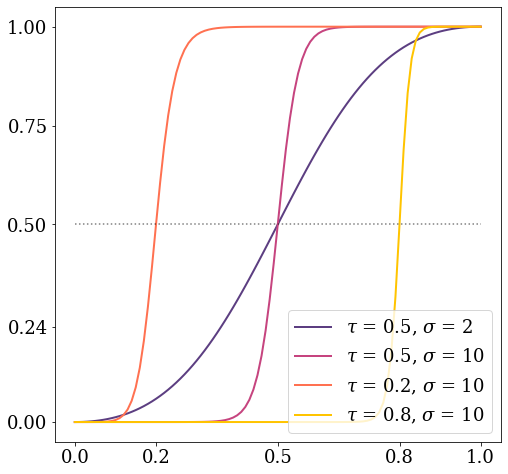

In [107]:
plt.rcParams["figure.figsize"] = (8,8)
p_list_1 = [response_probability(n_act, 100, 0.5, 2) for n_act in range(100+1)]
p_list_3 = [response_probability(n_act, 100, 0.5, 10) for n_act in range(100+1)]
p_list_4 = [response_probability(n_act, 100, 0.2, 10) for n_act in range(100+1)]
p_list_5 = [response_probability(n_act, 100, 0.8, 10) for n_act in range(100+1)]
plt.plot(np.linspace(0, 1, 101), p_list_1, color=colors_7[0], label=r'$\tau$ = 0.5, $\sigma$ = 2', linewidth=2)
plt.plot(np.linspace(0, 1, 101), p_list_3, color=colors_7[2], label=r'$\tau$ = 0.5, $\sigma$ = 10', linewidth=2)
plt.plot(np.linspace(0, 1, 101), p_list_4, color=colors_7[4], label=r'$\tau$ = 0.2, $\sigma$ = 10', linewidth=2)
plt.plot(np.linspace(0, 1, 101), p_list_5, color=colors_7[6], label=r'$\tau$ = 0.8, $\sigma$ = 10', linewidth=2)
plt.legend(fontsize=18, loc='lower right')
plt.xticks([0.0, 0.2, 0.5, 0.8, 1.0], fontsize=18)
plt.yticks([0.0, 0.24, 0.5, 0.75, 1.0], fontsize=18)
plt.hlines(0.5, 0, 1, linestyle='dotted', color='k', alpha=0.5)
plt.savefig('Figures/S-curves.svg')

### Figure 3

Panels a) and d)

In [25]:
# memberships requested
memberships = [10, 20, 30, 40, 50, 60, 70]

# Beta sweep
beta_values = np.linspace(0.0, 16/n_max, 100)

# storage: I_n[beta_index]
v_s = {m: np.zeros(len(beta_values)) for m in memberships}
v_s_act = {m: np.zeros(len(beta_values)) for m in memberships}
v_s_pass = {m: np.zeros(len(beta_values)) for m in memberships}
I = np.zeros(len(beta_values))
I_act = np.zeros(len(beta_values))
I_pass = np.zeros(len(beta_values))

for b_index, beta_minus in enumerate(beta_values):

    out = stationary_state(
        A=A, h=h, epsilon=epsilon,
        beta_minus=beta_minus,
        p_n=p_n, g_m=g_m,
        s=s, tau=tau,
        max_iter=600, tol=1e-12,
        init_state=None
    )
    
    v_s_plus  = out["v_s_plus"]
    v_s_minus = out["v_s_minus"]

    for m in memberships:

        # global mixture over node types
        v_s[m][b_index] = A*v_s_plus[m] + (1-A)*v_s_minus[m]
        v_s_act[m][b_index] = v_s_plus[m]
        v_s_pass[m][b_index] = v_s_minus[m]

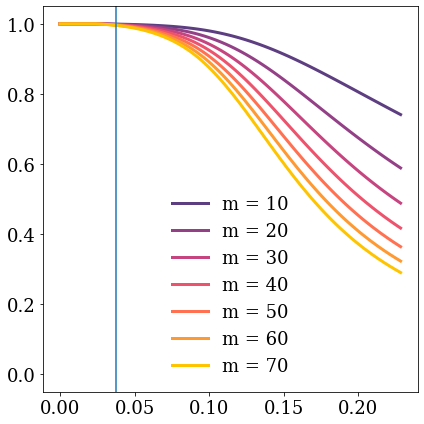

In [26]:
plt.figure(figsize=(6,6))

for idx, m in enumerate(memberships):
    plt.plot(beta_values, v_s_pass[m],
             color=colors_7[idx],
             lw=3,
             label=f"m = {m}")
    
#plt.xlabel(r"Transmission rate $\beta$", fontsize=16)
#plt.ylabel(r"Individual susceptibility $v_{s|m}$", fontsize=16)
plt.legend(fontsize=18, frameon=False)
plt.xticks([0.0, 0.05, 0.10, 0.15, 0.20], fontsize=18)
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=18)
plt.ylim([-0.05, 1.05])
plt.tight_layout()
plt.savefig('Figures/NetSci Figures/Localization figure/Localized susceptibility.svg')
plt.show()

Panels b) and e)

In [25]:
# group sizes requested
group_sizes = [10, 20, 30, 40, 50, 60, 70]

# Beta sweep
beta_values = np.linspace(0.0, 16/n_max, 100)

# storage: I_n[beta_index]
I_n = {n: np.zeros(len(beta_values)) for n in group_sizes}

for b_index, beta_minus in enumerate(beta_values):

    out = stationary_state(
        A=A, h=h, epsilon=epsilon,
        beta_minus=beta_minus,
        p_n=p_n, g_m=g_m,
        s=s, tau=tau,
        max_iter=600, tol=1e-12,
        init_state=None
    )
    
    c_state   = out["c_state"]
    P_sigma_n = out["P_sigma_n"]

    for n in group_sizes:

        # global mixture over group types
        P_plus  = P_sigma_n[n]["{+}"]
        P_minus = P_sigma_n[n]["{-}"]

        c_plus  = c_state[(n, "{+}")]
        c_minus = c_state[(n, "{-}")]

        c_global = P_plus*c_plus + P_minus*c_minus

        # group prevalence: sum_i (i/n) c_{i|n}
        i_vals = np.arange(n+1)
        I_n[n][b_index] = np.sum((i_vals/n) * c_global)

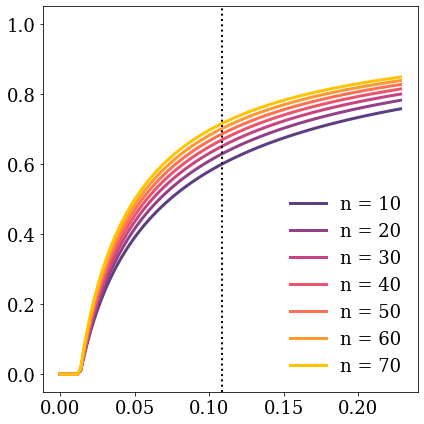

In [137]:
plt.figure(figsize=(6,6))

for idx, n in enumerate(group_sizes):
    plt.plot(beta_values, I_n[n],
             color=colors_7[idx],
             lw=3,
             label=f"n = {n}")
    
#plt.xlabel(r"Transmission rate $\beta$", fontsize=16)
#plt.ylabel(r"Group prevalence $I_n$", fontsize=16)
plt.legend(fontsize=18, frameon=False)
plt.axvline(7.6/n_max, color='black', linestyle='dotted', linewidth=2)
plt.xticks([0.0, 0.05, 0.10, 0.15, 0.20], fontsize=18)
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=18)
plt.ylim([-0.05, 1.05])
plt.tight_layout()
plt.savefig('Figures/NetSci Figures/Localization figure/Delocalized prevalence.svg')
plt.show()

In [ ]:
i=0
#Shows smoothed histogram of c_{i|n} for n in the list below
out = stationary_state(
        A=A, h=h, epsilon=epsilon,
        beta_minus=7.6/n_max,
        p_n=p_n, g_m=g_m,
        s=s, tau=tau,
        max_iter=600, tol=1e-12,
        init_state=None
    )
    
c_state = out["c_state"]
P_sigma_n = out["P_sigma_n"]

for n in [10, 20, 30, 40, 50, 60, 70]:
    # global mixture over group types
    P_plus  = P_sigma_n[n]["{+}"]
    P_minus = P_sigma_n[n]["{-}"]

    c_plus  = c_state[(n, "{+}")]
    c_minus = c_state[(n, "{-}")]

    c_global = P_plus*c_plus + P_minus*c_minus
    c_global /= np.amax(c_global)
    smooth_data_loc = make_interp_spline(np.linspace(0, 1, n+1), c_global, k=n-1)
        
    x=np.linspace(0, 1, 300)
    
    #The interpolation lets values go below 0. This next loop fixes that, but the interpolation still isn't perfectly smooth.
    smooth_data_loc_list = []
    for elem in x:
        if smooth_data_loc(elem) < 0:
            smooth_data_loc_list.append(0)
        else:
            smooth_data_loc_list.append(smooth_data_loc(elem))
            
    plt.figure(figsize=(9,3))        
    plt.plot(x, smooth_data_loc_list, color=colors_7[i], lw=3)
    plt.fill_between(x, smooth_data_loc_list, color=colors_7[i], alpha=0.1)
    plt.ylim([-0.05, 1.05])
    plt.axis('off')
    plt.savefig('Figures/NetSci Figures/Localization figure/Ridgeline/Localized_{}.pdf'.format(n))
    plt.show()
    i+=1

### Figure 4

Panels b, c, e and f

In [26]:
# group sizes requested
group_sizes = [5, 70]

# Beta sweep
beta_values = np.linspace(0.0, 16/n_max, 100)

# storage: I_n[beta_index]
I_n = {n: np.zeros(len(beta_values)) for n in group_sizes}
I_n_plus = {n: np.zeros(len(beta_values)) for n in group_sizes}
I_n_minus = {n: np.zeros(len(beta_values)) for n in group_sizes}
I_act = np.zeros(len(beta_values))
I_pass = np.zeros(len(beta_values))
I = np.zeros(len(beta_values))

for b_index, beta_minus in enumerate(beta_values):

    out = stationary_state(
        A=A, h=h, epsilon=epsilon,
        beta_minus=beta_minus,
        p_n=p_n, g_m=g_m,
        s=s, tau=tau,
        max_iter=600, tol=1e-12,
        init_state=None
    )
    
    c_state   = out["c_state"]
    P_sigma_n = out["P_sigma_n"]
    
    for n in range(n_min, n_max+1):
        # global mixture over group types
        P_plus  = P_sigma_n[n]["{+}"]
        P_minus = P_sigma_n[n]["{-}"]

        c_plus  = P_plus*c_state[(n, "{+}")]
        c_minus = P_minus*c_state[(n, "{-}")]

        c_global = c_plus + c_minus
        
        # group prevalence: sum_i (i/n) c_{i|n}
        i_vals = np.arange(n+1)
        if n in group_sizes:
            I_n[n][b_index] = np.sum((i_vals/n) * c_global)
            I_n_plus[n][b_index] = np.sum((i_vals/n) * c_plus)
            I_n_minus[n][b_index] = np.sum((i_vals/n) * c_minus)

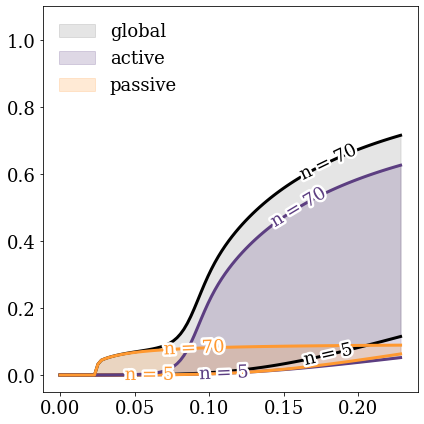

In [27]:
plt.figure(figsize=(6,6))

for idx, n in enumerate(group_sizes):
    line1 = plt.plot(beta_values, I_n[n], color='k',
             lw=3,
             label=f"n = {n}")
    line2 = plt.plot(beta_values, I_n_plus[n], color=colors_7[0],
             lw=3,
             label=f"n = {n}")
    line3 = plt.plot(beta_values, I_n_minus[n], color=colors_7[5],
             lw=3,
             label=f"n = {n}")
fill1 = plt.fill_between(beta_values, I_n[group_sizes[0]], I_n[group_sizes[-1]], color='k', alpha=0.1, label='global')
fill2 = plt.fill_between(beta_values, I_n_plus[group_sizes[0]], I_n_plus[group_sizes[-1]], color=colors_7[0], alpha=0.2, label='active')
fill3 = plt.fill_between(beta_values, I_n_minus[group_sizes[0]], I_n_minus[group_sizes[-1]], color=colors_7[5], alpha=0.2, label='passive')
xvals = [0.18, 0.11, 0.06, 0.18, 0.16, 0.09] #Label the lines within the plot (needed when legend fits awkwardly)
labelLines(plt.gca().get_lines(), zorder=2.5, fontsize=18, xvals=xvals)

#plt.xlabel(r"Transmission rate $\beta$", fontsize=18)
plt.legend(fontsize=18, handles=[fill1, fill2, fill3], frameon=False, loc='upper left')
plt.xticks([0.0, 0.05, 0.10, 0.15, 0.20], fontsize=18)
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=18)
plt.ylim([-0.05, 1.10])
plt.tight_layout()
plt.savefig('Figures/NetSci Figures/Influential type figure/Hom_0_inf_04.svg')
plt.show()

Panels a and d

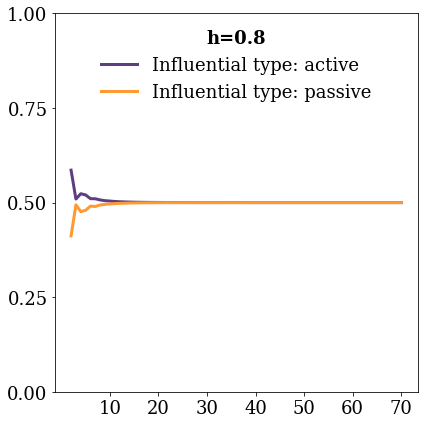

In [39]:
plt.figure(figsize=(6,6))
h=0.8
P_nplus_n = [composition_distribution(n, A, h) for n in range(n_min, n_max+1)]
plt.plot(range(n_min, n_max+1), [P_pm_given_n(n, P_nplus_n[n-n_min], 0.4, 10)[0] for n in range(n_min, n_max+1)], color = purple_7[0], linewidth=3, label='Influential type: active')
plt.plot(range(n_min, n_max+1), [P_pm_given_n(n, P_nplus_n[n-n_min], 0.6, 10)[0] for n in range(n_min, n_max+1)], color = orange_7[0], linewidth=3, label='Influential type: passive')
plt.xticks([10, 20, 30, 40, 50, 60, 70], fontsize=18)
plt.yticks([0.0, 0.25, 0.5, 0.75, 1.0], fontsize=18)
#plt.xlabel(r'Group size n', fontsize='20')
#plt.ylabel(r'Fraction of active groups P$_{\{+\}|\text{n}}$', fontsize='20')
plt.legend(fontsize='18', frameon=False, loc='upper center', title='h=0.8', title_fontproperties={'size':'18', 'weight':'bold'})
plt.tight_layout()
plt.savefig('Figures/NetSci Figures/Influential type figure/Panel_d.svg')
plt.show()

### Figure 5

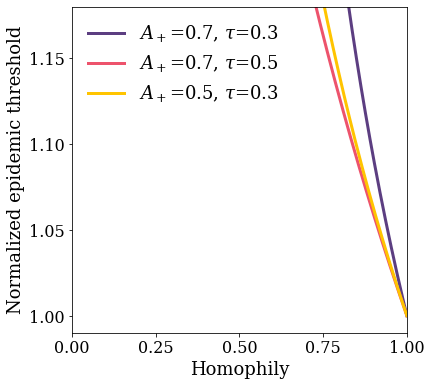

In [115]:
plt.rcParams["figure.figsize"] = (6, 6)
params = [[0.3, 0.7], [0.5, 0.7], [0.3, 0.5]]
thresh_1 = [analytic_threshold(s, h, params[0][0], params[0][1], 0.2, 2.6, 3.2, n_min, n_max, m_min, m_max) for h in np.linspace(0, 1.0, 300)]/analytic_threshold(s, 1.0, params[0][0], params[0][1], epsilon, 2.6, 3.2, n_min, n_max, m_min, m_max)
thresh_2 = [analytic_threshold(s, h, params[1][0], params[1][1], 0.2, 2.6, 3.2, n_min, n_max, m_min, m_max) for h in np.linspace(0, 1.0, 300)]/analytic_threshold(s, 1.0, params[1][0], params[1][1], epsilon, 2.6, 3.2, n_min, n_max, m_min, m_max)
thresh_3 = [analytic_threshold(s, h, params[2][0], params[2][1], 0.2, 2.6, 3.2, n_min, n_max, m_min, m_max) for h in np.linspace(0, 1.0, 300)]/analytic_threshold(s, 1.0, params[2][0], params[2][1], epsilon, 2.6, 3.2, n_min, n_max, m_min, m_max)

plt.plot(np.linspace(0, 1.0, 300), thresh_1, label=r'$A_+$={0}, $\tau$={1}'.format(params[0][1], params[0][0]), color=colors_7[0], linewidth=3)
plt.plot(np.linspace(0, 1.0, 300), thresh_2, label=r'$A_+$={0}, $\tau$={1}'.format(params[1][1], params[1][0]), color=colors_7[3], linewidth=3)
plt.plot(np.linspace(0, 1.0, 300), thresh_3, label=r'$A_+$={0}, $\tau$={1}'.format(params[2][1], params[2][0]), color=colors_7[6], linewidth=3)

plt.legend(fontsize=18, frameon=False)
plt.xticks([0, 0.25, 0.5, 0.75, 1], fontsize=16)
plt.xlim([0, 1])
plt.ylim([0.9, 4.1])
plt.yticks([1.00, 2.00, 3.00, 4.00], fontsize=16)
plt.xlabel('Homophily', fontsize=18)
plt.ylabel('Normalized epidemic threshold', fontsize=18)
plt.savefig('Figures/Analytic_relative_threshold_homophily_active.svg')
plt.show()

## Figure 6

In [106]:
invphi = (np.sqrt(5) - 1) / 2
gamma_m = 3.2
n_min=2
m_min=2
m_max=70
monotonicity_thresh = [[], [], []]
dh = 1/300
gamma_n_list=[0, 2.3047, 2.98713, 3.29533, 3.46353, 3.56635, 3.63421, 3.68155, 3.71599, 3.74191, 3.76193, 3.77774, 3.79047, 3.80087, 3.8095, 3.81673, 3.82286, 3.82811, 3.83263, 3.83656, 3.84, 3.84303, 3.84571, 3.84809, 3.85022, 3.85213, 3.85386, 3.85542, 3.85683, 3.85812, 3.8593, 3.86037, 3.86136, 3.86228, 3.86312, 3.86369, 3.86462, 3.86529, 3.86591, 3.86649, 3.86703, 3.86754, 3.86801, 3.86846, 3.86888, 3.86927, 3.86964, 3.86999, 3.87032, 3.87063, 3.87093, 3.87121, 3.87147, 3.87172, 3.87196, 3.87219, 3.87241, 3.87261, 3.87281, 3.873, 3.87317, 3.87335, 3.87351, 3.87367, 3.87381, 3.87396, 3.8741, 3.87423, 3.87435, 3.87448, 3.87459, 3.8747, 3.87481, 3.87492, 3.87502, 3.87511, 3.87521, 3.8753]
i = 0
low = False
for params in [[0.6, 0.45], [0.7, 0.5], [0.7, 0.3]]:
    for n_max in tqdm(range(3, 80)):
        h1 = 0
        h2 = 1
        h3 = h2 - (h2 - h1) * invphi
        h4 = h1 + (h2 - h1) * invphi
        thresh_1 = analytic_threshold(10, h3, params[0], params[1], 0.2, gamma_n_list[n_max-3], gamma_m, 2, n_max, 2, 70)
        thresh_2 = analytic_threshold(10, h4, params[0], params[1], 0.2, gamma_n_list[n_max-3], gamma_m, 2, n_max, 2, 70)
        while h2 - h1 > 1e-5:
            if thresh_1 > thresh_2:
                h2 = h4
                h4, thresh_2 = h3, thresh_1
                h3 = h2 - (h2 - h1) * invphi
                thresh_1 = analytic_threshold(10, h3, params[0], params[1], 0.2, gamma_n_list[n_max-3], gamma_m, 2, n_max, 2, 70)
                low = True
            else:
                h1 = h3
                h3, thresh_1 = h4, thresh_2
                h4 = h1 + (h2 - h1) * invphi
                thresh_2 = analytic_threshold(10, h4, params[0], params[1], 0.2, gamma_n_list[n_max-3], gamma_m, 2, n_max, 2, 70)
                low = False
        if low:
            monotonicity_thresh[i].append(h1)
        else:
            monotonicity_thresh[i].append(h2)
    i += 1

100%|██████████| 77/77 [02:14<00:00,  1.74s/it]


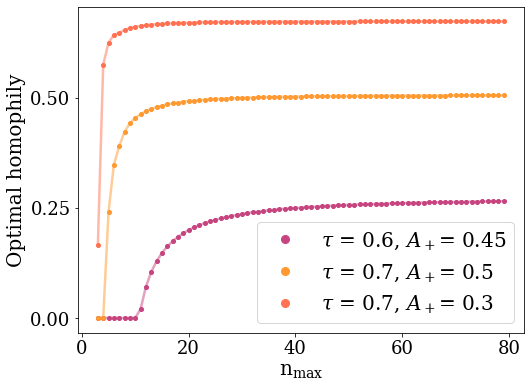

In [107]:
plt.figure(figsize=(8,6))
plt.plot(range(3, 80), monotonicity_thresh[0], label=r'$\tau$ = 0.6, $A_+$= 0.45', marker='o', color=colors_7[2], linestyle='None', markersize=4)
plt.plot(range(3, 80), monotonicity_thresh[0], color=colors_7[2], linewidth=2.5, alpha=0.5)
plt.plot(range(3, 80), monotonicity_thresh[1], label=r'$\tau$ = 0.7, $A_+$= 0.5', marker='o', color = colors_7[5], linestyle='None', markersize=4)
plt.plot(range(3, 80), monotonicity_thresh[1], color = colors_7[5], linewidth=2.5, alpha=0.5)
plt.plot(range(3, 80), monotonicity_thresh[2], label=r'$\tau$ = 0.7, $A_+$= 0.3', marker='o', color = colors_7[4], linestyle='None', markersize=4)
plt.plot(range(3, 80), monotonicity_thresh[2], color = colors_7[4], linewidth=2.5, alpha=0.5)
plt.xlabel(r'n$_{\text{max}}$', fontsize=20)
plt.ylabel('Optimal homophily', fontsize=20)
plt.legend(fontsize=20, markerscale=2.)
plt.xticks([0, 20, 40, 60, 80], fontsize=18)
plt.yticks([0, 0.25, 0.5], fontsize=18)
plt.savefig('Figures/Impact_n_max.pdf')
plt.show()

## Figure 7 - MC Validation

In [9]:
# parameters
A       = 0.5     # fraction active nodes
h       = 0.0     # homophily
epsilon = 0.2     # efficiency
s       = 10      # steepness of response distribution
tau     = 0.6     # influence parameter
gamma_n = 2.6
gamma_m = 3.2
n_min   = 2
n_max   = 70
m_min   = 2
m_max   = 70

# membership distribution g_m (example)
g_m = {m: p(m, gamma_m, n_min=m_min, n_max=m_max) for m in range(m_min, m_max+1)}   # uniform for demonstration

# group size distribution p_n (constructed from your chosen sizes)
p_n = {n: p(n, gamma_n, n_min=n_min, n_max=n_max) for n in range(n_min, n_max+1)}
# group sizes requested
group_sizes = [5, 10, 20, 30, 50, 70]

# Beta sweep
beta_values = np.linspace(0.0, 8/n_max, 60)

# storage: I_n[beta_index]
I_n = {n: np.zeros(len(beta_values)) for n in group_sizes}

for b_index, beta_minus in enumerate(beta_values):

    out = stationary_state(
        A=A, h=h, epsilon=epsilon,
        beta_minus=beta_minus,
        p_n=p_n, g_m=g_m,
        s=s, tau=tau,
        max_iter=600, tol=1e-12,
        init_state=None
    )
    
    c_state   = out["c_state"]
    P_sigma_n = out["P_sigma_n"]

    for n in group_sizes:

        # global mixture over group types
        P_plus  = P_sigma_n[n]["{+}"]
        P_minus = P_sigma_n[n]["{-}"]

        c_plus  = c_state[(n, "{+}")]
        c_minus = c_state[(n, "{-}")]

        c_global = P_plus*c_plus + P_minus*c_minus

        # group prevalence: sum_i (i/n) c_{i|n}
        i_vals = np.arange(n+1)
        I_n[n][b_index] = np.sum((i_vals/n) * c_global)

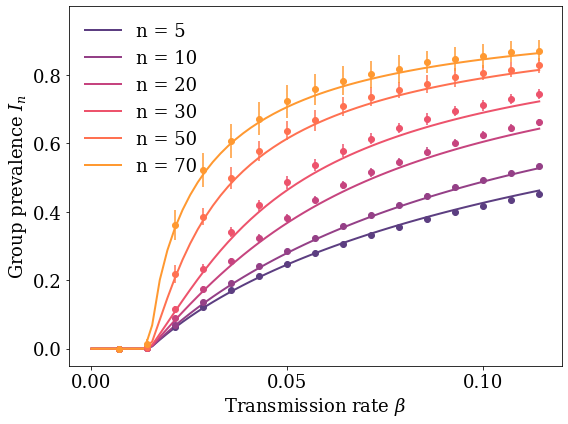

In [10]:
# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

mult_list = [i/(2*n_max) for i in range(1, 17)]
### These values are generated from the AME_MC_Simulation notebook
means_array = [[9.293008074510162e-05, 0.0012794629265534907, 0.06438298088864604, 0.12158933149494319, 0.17081367538316358, 0.21130825851314075, 0.24684848678879592, 0.2792625406856831, 0.30689571418624756, 0.33335831250377534, 0.35637023606632373, 0.3785970658617952, 0.39798886185935073, 0.41682614617193414, 0.4339542230415332, 0.4506502596722317], [0.00010903675534045554, 0.0013671790436374036, 0.0706281159368848, 0.13523138925130124, 0.19205953611053359, 0.24169295997127643, 0.28489586921231813, 0.32313195405158257, 0.3592273889287462, 0.3915124959615477, 0.4192859093975706, 0.4473723106287809, 0.4717353411484396, 0.49402249771110646, 0.5142404052436784, 0.5334302803558159], [0.00012354268558600637, 0.0016359423385811271, 0.08841004034070735, 0.1740987239073208, 0.25545958104805505, 0.32368291676890915, 0.3824126127282809, 0.43552576276819344, 0.4783009623803554, 0.5149514200515727, 0.5467057777945677, 0.5759576278812614, 0.6023373249973172, 0.6244732606734095, 0.6461069337860901, 0.6612154619643043], [0.00015621908804220008, 0.0020040735006195227, 0.11464124603741277, 0.23374957806019206, 0.3397694081882171, 0.4189465242384522, 0.4863191850123214, 0.5367726395307438, 0.5787193494480234, 0.6134368919740593, 0.6453553474931868, 0.6708565970971787, 0.6942443545650149, 0.7108250966936316, 0.7283213750100246, 0.7432156378937524], [0.0002421065691036152, 0.003748750748041791, 0.2176593836292367, 0.38615328839067675, 0.49927178531039446, 0.5769505419835279, 0.6367813910795093, 0.6669133042974129, 0.7084581229777823, 0.73620435826441, 0.7560494608715467, 0.7729709361094437, 0.7923264866094313, 0.8064220728702595, 0.8152662054665422, 0.8281805744821631], [0.00037019747217068645, 0.013251823046992689, 0.3619255804522858, 0.5220885788219717, 0.6080421739609596, 0.6724954379043575, 0.7224358908353552, 0.7576428641061319, 0.7832212562477205, 0.8014415458172781, 0.8169033157308961, 0.8374886265480552, 0.8474466943126319, 0.8549774139511283, 0.8679115708359101, 0.8711565325042022]]
stdv_array = [[7.82167814477908e-05, 0.0011683577359275002, 0.0038366233746826048, 0.003458254659570078, 0.004000994987158427, 0.004557960810089352, 0.004219868107304956, 0.004607039829189677, 0.004716195329512849, 0.00471855425323934, 0.004715158210199659, 0.004333667405982489, 0.0042439794879580465, 0.0042841525734091, 0.004600593927309218, 0.004507059161135798], [0.00012431591941536768, 0.001287308970095388, 0.004310627453772508, 0.0046909678953184295, 0.004211041650445762, 0.005111275781911863, 0.005439373335150856, 0.005794558956771129, 0.0058663919379954195, 0.006020930443390505, 0.0052897070544563485, 0.006283316067461661, 0.00595557513398912, 0.005637581843142209, 0.004061091851541844, 0.00532855213966345], [0.0002108406447799824, 0.0016065797704525053, 0.006375319496544412, 0.008389966349772212, 0.008081587680671052, 0.01030131808935473, 0.011671091766813907, 0.010622652189810223, 0.012849885590867891, 0.013146187984431984, 0.00991844305112712, 0.013965747449648434, 0.01015748634272197, 0.01058831132417715, 0.009157836377693492, 0.010102244117466918], [0.0003270419793745076, 0.002201490863846125, 0.01124512243166697, 0.013622043945965945, 0.014621723958959585, 0.015584909079537967, 0.01954759460777732, 0.01820576742514869, 0.018191937251393394, 0.01632109688007788, 0.01454799455925789, 0.017973671694633247, 0.014602910589963988, 0.015921536506971465, 0.01482950535986928, 0.014886430884502585], [0.0007191190559517303, 0.004672953776348076, 0.02540529217143874, 0.02468743274331204, 0.032457938719370596, 0.029176983201221886, 0.027794559071356365, 0.030990591638192077, 0.027938345058061025, 0.027364137187796882, 0.023873815497101557, 0.0271871297013827, 0.026430731650530143, 0.022604183440654055, 0.02220763756271795, 0.02149048838042835], [0.0012665782952135148, 0.016362624290897795, 0.043000466345849045, 0.048395045007566105, 0.04975502159697393, 0.049183038333448746, 0.04748757341265398, 0.044360834065307136, 0.04258019265552977, 0.03969911148203276, 0.039865522441536905, 0.031069143290635644, 0.03522875385996527, 0.03484299549668871, 0.03152970127723612, 0.03136456600650119]]

plt.figure(figsize=(8,6))

for idx, n in enumerate(group_sizes):
    plt.plot(beta_values, I_n[n],
             color=colors_7[idx],
             lw=2,
             label=f"n = {n}")
    plt.errorbar(mult_list, means_array[idx], yerr=stdv_array[idx], color=colors_7[idx], marker='o', linestyle='None')

plt.xlabel(r"Transmission rate $\beta$", fontsize=18)
plt.ylabel(r"Group prevalence $I_n$", fontsize=18)
plt.legend(fontsize=18, frameon=False)
plt.xticks([0.0, 0.05, 0.10], fontsize=18)
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8], fontsize=18)
plt.ylim([-0.05, 1.0])
plt.tight_layout()
plt.savefig('Figures/MC_validation_bifurcation_diagram.svg')
plt.show()

## Figure 8

In [13]:
#These values must be generated in the AME_MC_simulations notebook
thresh_hom_mean = [[0.031574297879849306, 0.027946319951634928, 0.022169034660336026, 0.019532570923554704, 0.01773451385646567, 0.016575385572449405, 0.015465299386159094, 0.0151791893286646, 0.014545925461497227, 0.014379386593479456, 0.013738406850098054], [0.013782234576512334, 0.013789472416140898, 0.013797375308318434, 0.01438158850558012, 0.014730464485615897, 0.01512925182509671, 0.015064436444673288, 0.015080327102976384, 0.014518118955568293, 0.014150973271955532, 0.013848971530368149]]

thresh_hom_stdv = [[0.008004334585021037, 0.00572946890189738, 0.0038536364035616608, 0.0012895850384298058, 0.0014104096771683007, 0.0010784025187492619, 0.000591930661054599, 0.0007437453256413047, 0.00081450330277189, 0.0007344061963261547, 0.0006337978045642388], [0.0006347548240141625, 0.0005564073239797344, 0.0007255527617348988, 0.0005476698502423727, 0.0006454184423759634, 0.0010341740211245616, 0.0007245765237239385, 0.0006873066768314785, 0.0007422607522249159, 0.0007052052743110839, 0.0006336835463831968]]

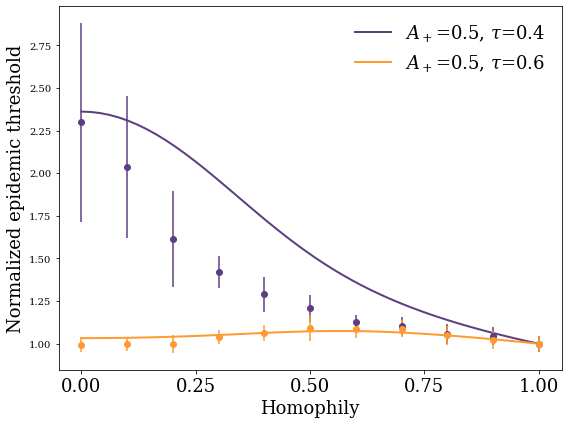

In [123]:
plt.rcParams["figure.figsize"] = (8, 6)

x = np.linspace(0, 1.0, 11)
y = np.linspace(0, 1.0, 50)
plt.errorbar(x, np.array(thresh_hom_mean[0])/thresh_hom_mean[0][-1], yerr=np.array(thresh_hom_stdv[0])/thresh_hom_mean[0][-1], linestyle='None', marker='o', color=colors_7[0])
plt.plot(y, np.array([analytic_threshold(10, h, 0.3, 0.5, 0.2, 2.6, 3.2, 2, 70, 2, 70) for h in y])/analytic_threshold(10, 1.0, 0.3, 0.5, 0.2, 2.6, 3.2, 2, 70, 2, 70), color=colors_7[0], lw=2, label=r'$A_+$=0.5, $\tau$=0.4')

plt.errorbar(x, np.array(thresh_hom_mean[1])/thresh_hom_mean[1][-1], yerr=np.array(thresh_hom_stdv[1])/thresh_hom_mean[1][-1], linestyle='None', marker='o', color=colors_7[5])
plt.plot(y, np.array([analytic_threshold(10, h, 0.7, 0.5, 0.2, 2.6, 3.2, 2, 70, 2, 70) for h in y])/analytic_threshold(10, 1.0, 0.7, 0.5, 0.2, 2.6, 3.2, 2, 70, 2, 70), color=colors_7[5], lw=2, label=r'$A_+$=0.5, $\tau$=0.6')

plt.legend(fontsize=18, frameon=False)
plt.xticks([0.0, 0.25, 0.50, 0.75, 1.0], fontsize=18)
#plt.yticks([1.0, 1.1, 1.2], fontsize=18)
plt.xlabel('Homophily', fontsize=18)
plt.ylabel(r'Normalized epidemic threshold', fontsize=18)
plt.tight_layout()
plt.savefig('Figures/MC_validation_threshold.svg')
plt.show()